# TMT data

In multiplexing approaches, peptides from multiple different samples are analyzed simultaneously in a single mass spectrometry run. They can be distinguished by a covalent labeling with isobaric chemical _mass tags_. These tags are chemically equivalent (i.e. they behave the same in the LC run), and their isotopic mass is the same so that they show up at the same  `m/z` ratio in the MS1 scan. However, as the distribution of the isotopic atoms in the tags is different, they form distinct peaks in the MS2 scan, so that the peptides from different samples can be identified in the MS2 scan analysis. 

As reviewed in [Huang et al, 2020](https://doi.org/10.1074/mcp.RA120.002105), the data analysis for TMT data involves multiple normalization steps. 

## References

> Huang, Ting, Meena Choi, Manuel Tzouros, et al. “MSstatsTMT: Statistical Detection of Differentially Abundant Proteins in Experiments with Isobaric Labeling and Multiple Mixtures.” _Molecular & Cellular Proteomics_ 19, no. 10 (2020): 1706–23. [https://doi.org/10.1074/mcp.RA120.002105](https://doi.org/10.1074/mcp.RA120.002105).

> Plubell, D. L. et al. Extended Multiplexing of Tandem Mass Tags (TMT) Labeling Reveals Age and High Fat Diet Specific Proteome Changes in Mouse Epididymal Adipose Tissue. Mol Cell Proteomics 16, 873–890 (2017).


## Setup

In [ ]:
import alphapepttools as apt
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
def plot_distribution(adata: ad.AnnData, layer: str | None = None, title: str | None = None) -> tuple:
    """Plot feature distributions of samples for Khan 2018 - TMT dataset

    References
    ----------
    - https://pwilmart.github.io/IRS_normalization/understanding_IRS.html
    """
    long_df = (
        adata.to_df(layer=layer).merge(adata.obs, left_index=True, right_index=True).melt(id_vars=adata.obs.columns)
    )

    fig, axs = plt.subplots(1, 2, figsize=(18, 5), width_ratios=[3, 1])

    sns.boxplot(long_df, x="sample", y="value", ax=axs[0], color="#efefef")
    sns.stripplot(long_df, x="sample", y="value", ax=axs[0], size=0.2, color="#222222")
    axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=90, ha="center")

    color_mapping = {"1": "#ff0000", "2": "#00ff00", "3": "#0000ff"}
    sample_color_mapping = adata.obs["plex"].apply(lambda x: color_mapping[x]).to_dict()

    sns.kdeplot(long_df, x="value", hue="sample", legend=False, palette=sample_color_mapping, ax=axs[1])

    if title is not None:
        fig.suptitle(title)

    return fig, axs

## Data Preparation

In [ ]:
path = apt.data.get_data("khan2018")
adata = ad.read_h5ad(path)

/Users/lucas-diedrich/Documents/Projects/scverse/alphatools/programming/alphatools/docs/notebooks/tutorials/khan2018_murine-lense-tmt.h5ad already exists (1.5709991455078125 MB)


In [ ]:
adata = apt.pp.filter_data_completeness(adata, max_missing=0, action="drop")
adata.obs_names = adata.obs["sample"]
adata.var_names = adata.var["gene_symbol"]
adata.layers["raw"] = adata.X.copy()
apt.pp.nanlog(adata, base=2)
adata.layers["log2"] = adata.X.copy()
adata

INFO:root:pp.filter_data_completeness(): drop 2921 / 6076 features with >0.00 missing.


AnnData object with n_obs × n_vars = 18 × 3155
    obs: 'sample', 'plex', 'timepoint', 'development_stage', 'day_post_birth'
    var: 'gene_symbol', 'uniprot_ids'
    layers: 'raw', 'log2'

## Explore normalization strategies

### Raw data

  artists = ax.bxp(**boxplot_kws)

  axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=90, ha="center", )



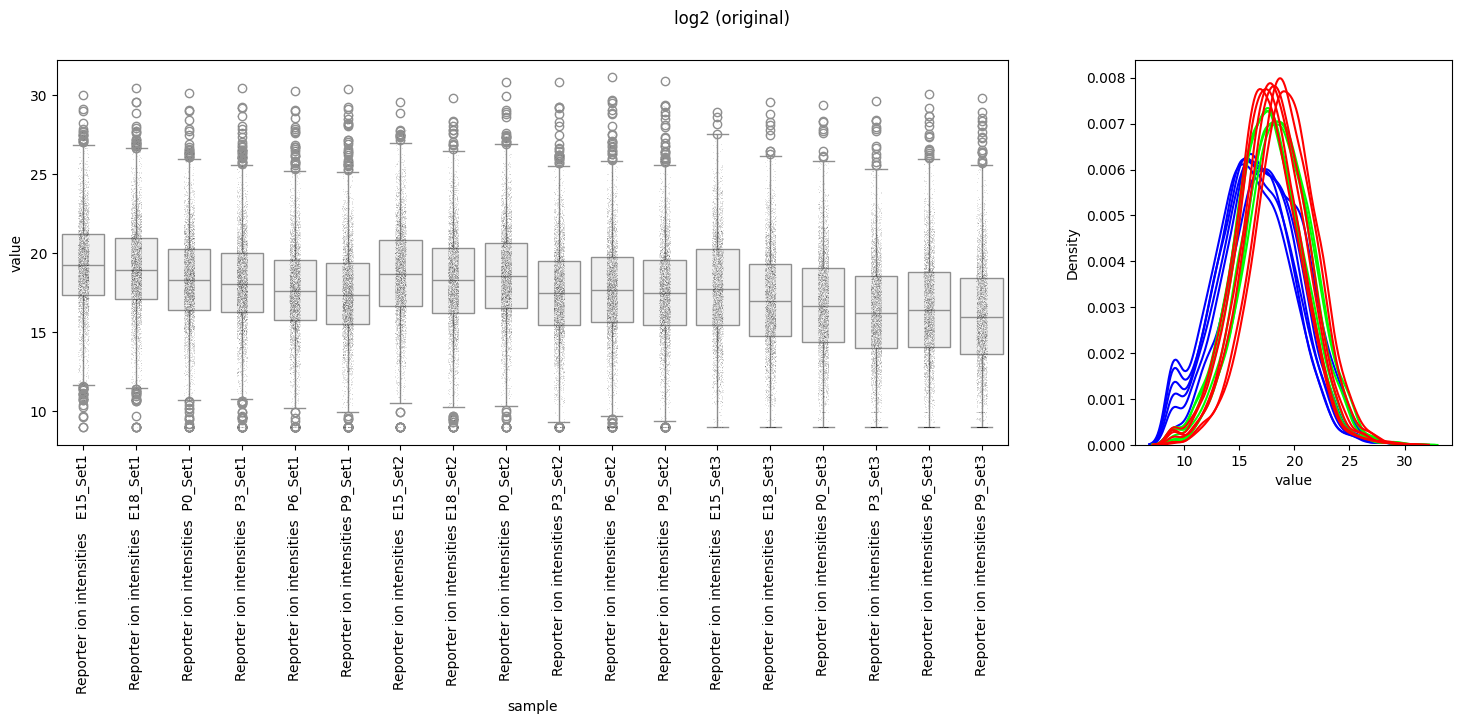

In [ ]:
plot_distribution(adata, layer="log2", title="log2 (original)")
plt.show()

### Total sum normalization (Sample Loading normalization)

In [ ]:
adata.layers["normalized__tss"] = adata.layers["raw"].copy()
apt.pp.normalize(adata, layer="normalized__tss", strategy="total_mean", group_column="plex")

adata.layers["log2_normalized__tss"] = adata.layers["normalized__tss"].copy()
apt.pp.nanlog(adata, base=2, layer="log2_normalized__tss")

  groups = adata.obs.groupby(group_column, dropna=True).indices



  artists = ax.bxp(**boxplot_kws)

  axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=90, ha="center", )



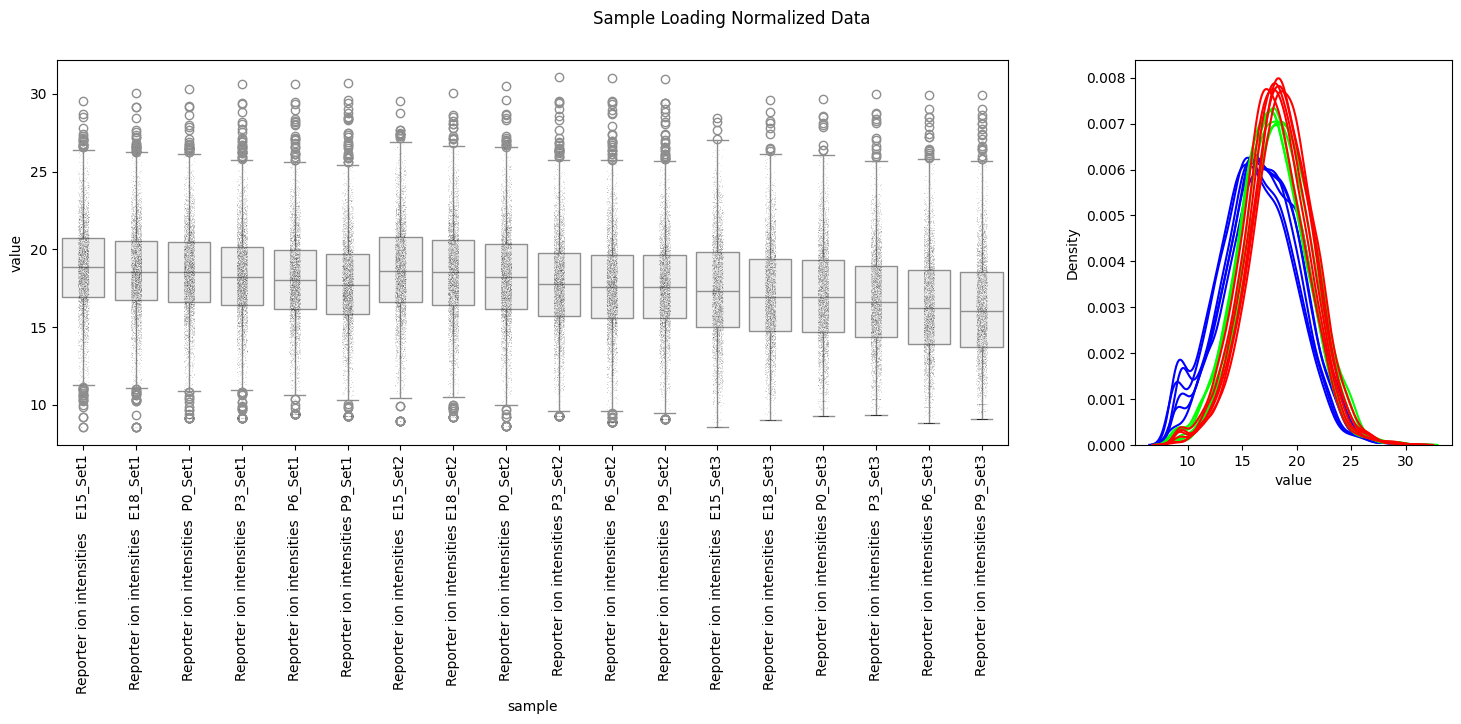

In [ ]:
plot_distribution(adata, layer="log2_normalized__tss", title="Sample Loading Normalized Data")
plt.show()

### Internal reference standard (IRS) normalization

In [ ]:
adata.layers["normalized__irs"] = adata.layers["normalized__tss"].copy()
apt.pp.irs(adata, group_column="plex", layer="normalized__irs", reference_column=None)

adata.layers["log2_normalized__irs"] = adata.layers["normalized__irs"].copy()
apt.pp.nanlog(adata, base=2, layer="log2_normalized__irs")

  groups = adata.obs.groupby(group_column, dropna=True)



  artists = ax.bxp(**boxplot_kws)

  axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=90, ha="center", )



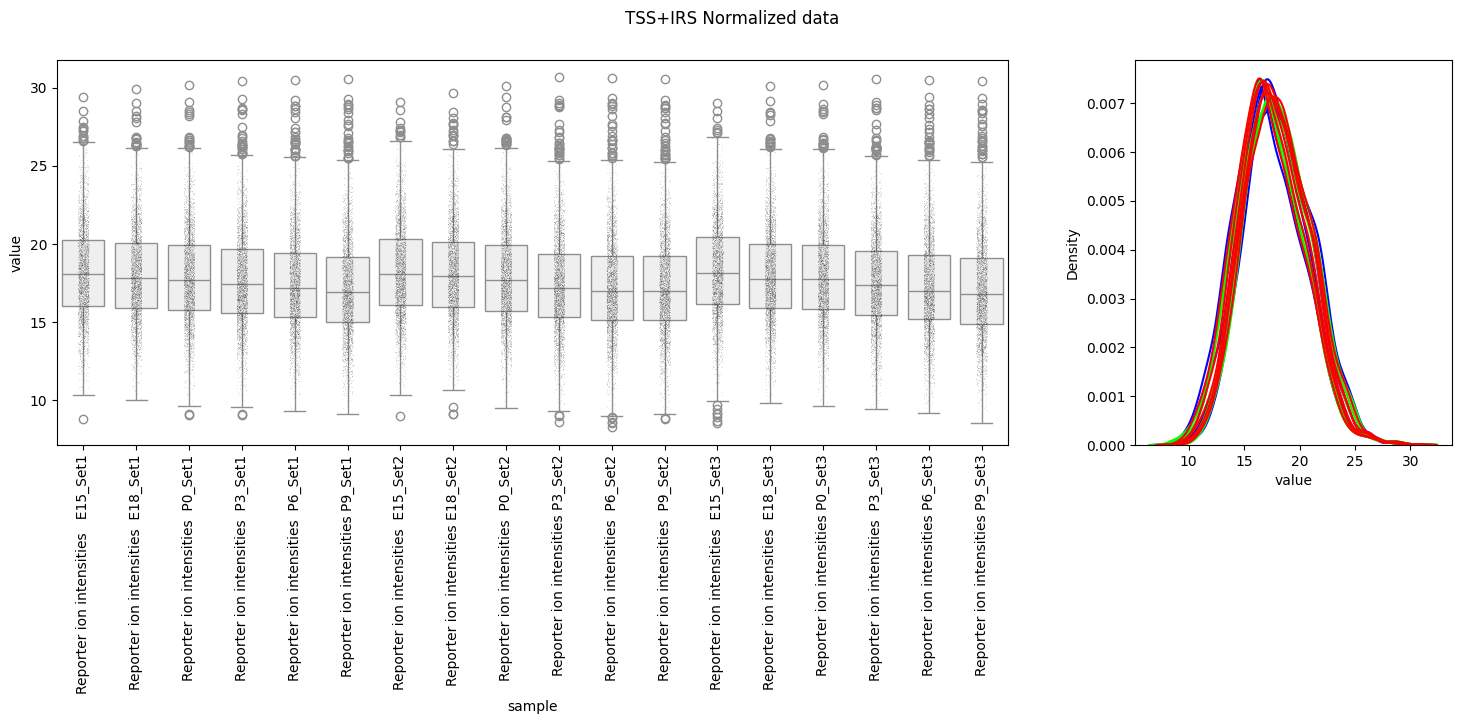

In [ ]:
plot_distribution(adata, layer="log2_normalized__irs", title="TSS+IRS Normalized data")
plt.show()

### Combat

In [ ]:
adata.layers["log2_combat"] = adata.layers["normalized__tss"].copy()
apt.pp.nanlog(
    adata, base=2, layer="log2_combat"
)  # important! Combat expects approximately normally distributed data. Log-transform first!
apt.pp.scanpy_pycombat(adata, batch="plex", covariates=None, layer="log2_combat")

INFO:alphapepttools.pp.batch_correction: scanpy_pycombat: pply pyComBat to correct for plex
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()

  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()



  artists = ax.bxp(**boxplot_kws)

  axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=90, ha="center", )



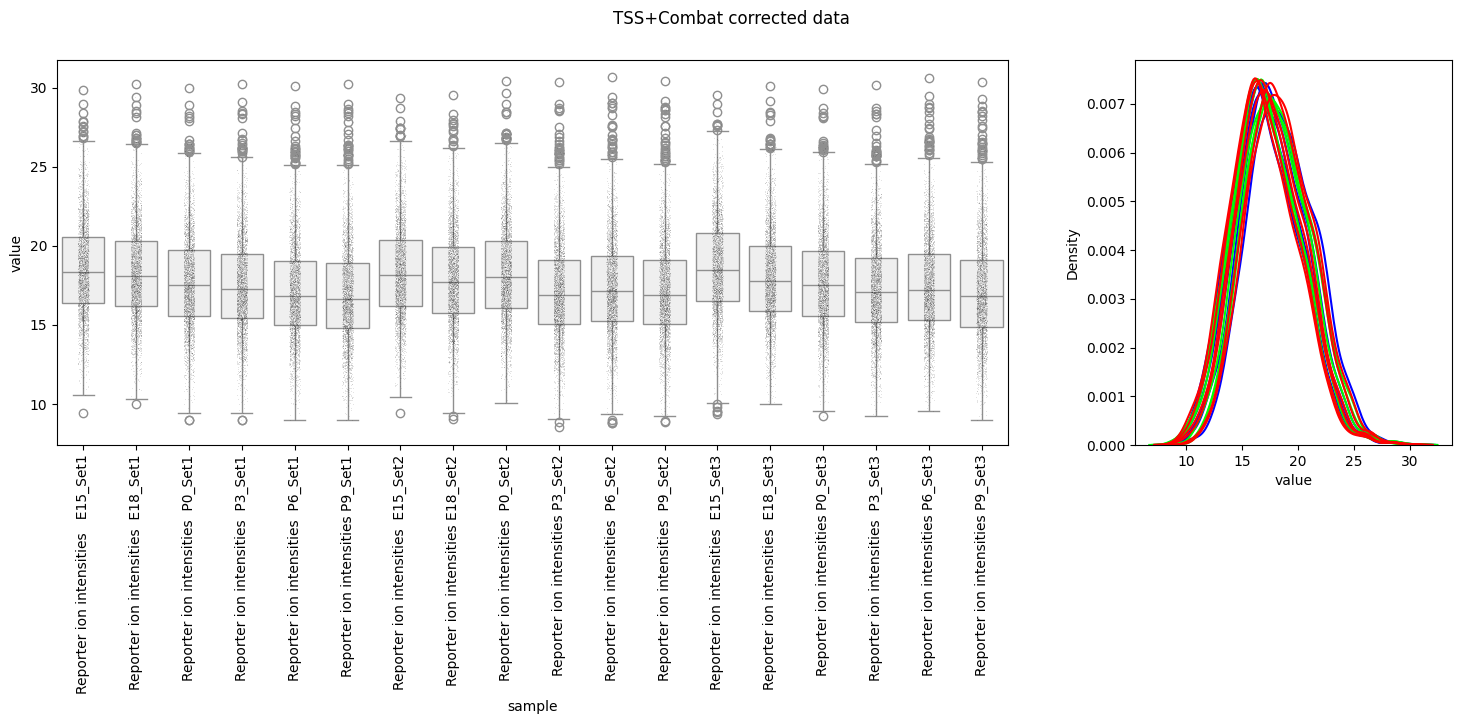

In [ ]:
plot_distribution(adata, layer="log2_combat", title="TSS+Combat corrected data")
plt.show()

## Exploration

In [ ]:
LAYERS = ("log2", "log2_normalized__tss", "log2_normalized__irs", "log2_combat")
LINEAR_LAYERS = ("raw", "normalized__tss", "normalized__irs")

for layer in LAYERS:
    apt.tl.pca(adata, layer=layer, embeddings_name=f"X_pca__{layer}")

INFO:alphapepttools.tl.embeddings:computing PCA
INFO:alphapepttools.tl.embeddings:computing PCA
INFO:alphapepttools.tl.embeddings:computing PCA
INFO:alphapepttools.tl.embeddings:computing PCA


  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)



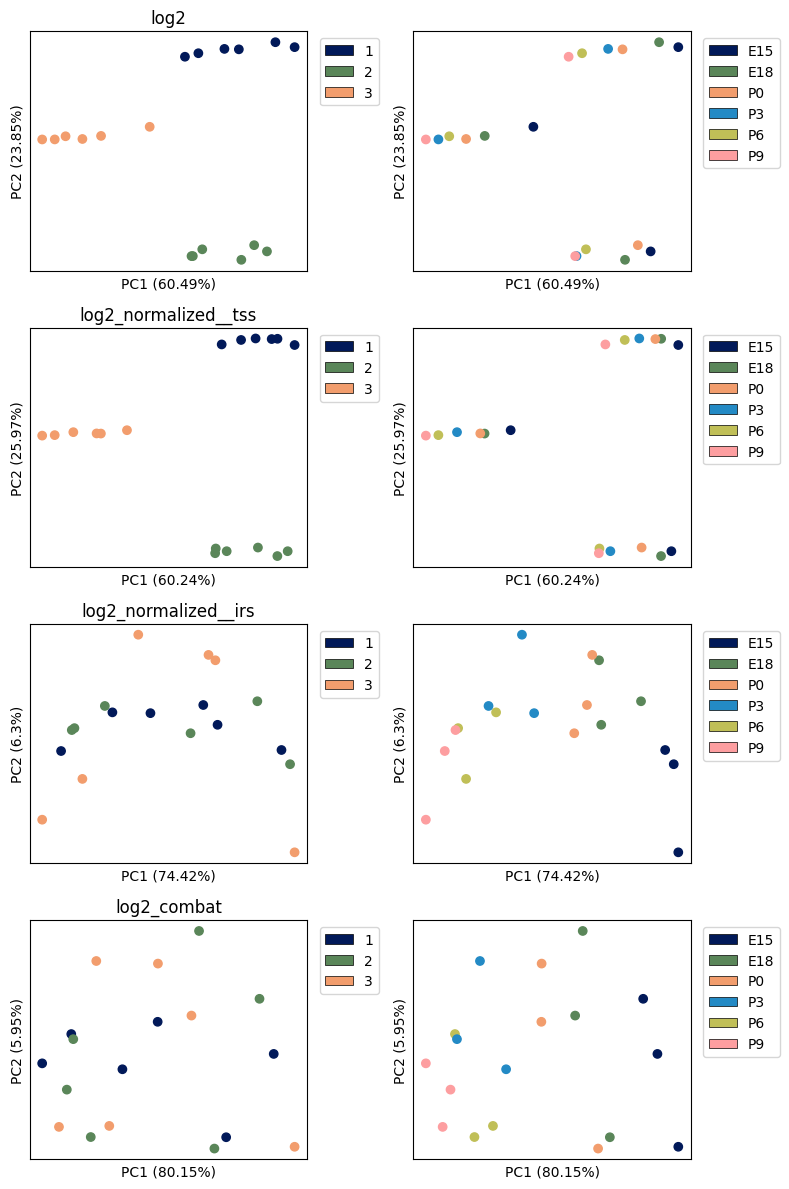

In [ ]:
fig, axs = plt.subplots(len(LAYERS), 2, figsize=(4 * 2, 3 * len(LAYERS)))


for idx, layer in enumerate(LAYERS):
    apt.pl.plot_pca(adata, embeddings_name=f"X_pca__{layer}", ax=axs[idx, 0], color_map_column="plex", legend="auto")
    apt.pl.plot_pca(
        adata, embeddings_name=f"X_pca__{layer}", ax=axs[idx, 1], color_map_column="timepoint", legend="auto"
    )
    axs[idx, 0].set_title(layer)

for ax in axs.ravel():
    # Move legend position
    legend = ax.get_legend()
    legend.set_loc("upper left")
    legend.set_bbox_to_anchor((1.02, 1))

    # Remove ticks
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

## Metrics

  groups = adata.obs.groupby(group_column)

  groups = adata.obs.groupby(group_column)

  groups = adata.obs.groupby(group_column)

  groups = adata.obs.groupby(group_column)

  groups = adata.obs.groupby(group_column)

  groups = adata.obs.groupby(group_column)

  groups = adata.obs.groupby(group_column)

  artists = ax.bxp(**boxplot_kws)

  artists = ax.bxp(**boxplot_kws)

  artists = ax.bxp(**boxplot_kws)

  artists = ax.bxp(**boxplot_kws)

  axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45, ha="right")

  artists = ax.bxp(**boxplot_kws)

  artists = ax.bxp(**boxplot_kws)

  artists = ax.bxp(**boxplot_kws)

  axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45, ha="right")



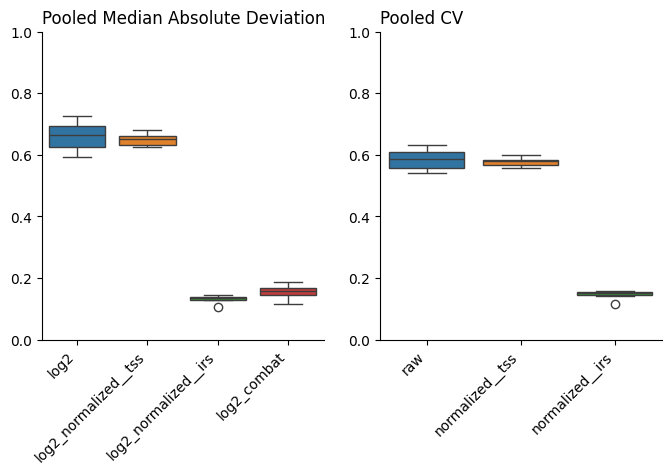

In [ ]:
pmad_results = {}
cv_results = {}
for layer in LAYERS:
    pmad_results[layer] = apt.metrics.pooled_median_absolute_deviation(adata, group_column="timepoint", layer=layer)

for layer in LINEAR_LAYERS:
    cv_results[layer] = apt.metrics.pooled_coefficient_of_variation(adata, group_column="timepoint", layer=layer)

pmad_results = pd.concat(pmad_results, axis=1).droplevel(level=1, axis=1)
cv_results = pd.concat(cv_results, axis=1).droplevel(level=1, axis=1)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

sns.boxplot(pmad_results, ax=axs[0])
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45, ha="right")
axs[0].set_title("Pooled Median Absolute Deviation", loc="left")
axs[0].set_ylim(0, 1)

sns.boxplot(cv_results, ax=axs[1])
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45, ha="right")
axs[1].set_title("Pooled CV", loc="left")
axs[1].set_ylim(0, 1)

for ax in axs.ravel():
    ax.spines[["top", "right"]].set_visible(False)

In [ ]:
# !pip install scib-metrics

In [ ]:
from scib_metrics import silhouette_label

  from .autonotebook import tqdm as notebook_tqdm

  warn(



INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/lucas-diedrich/mamba/envs/alphatools/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


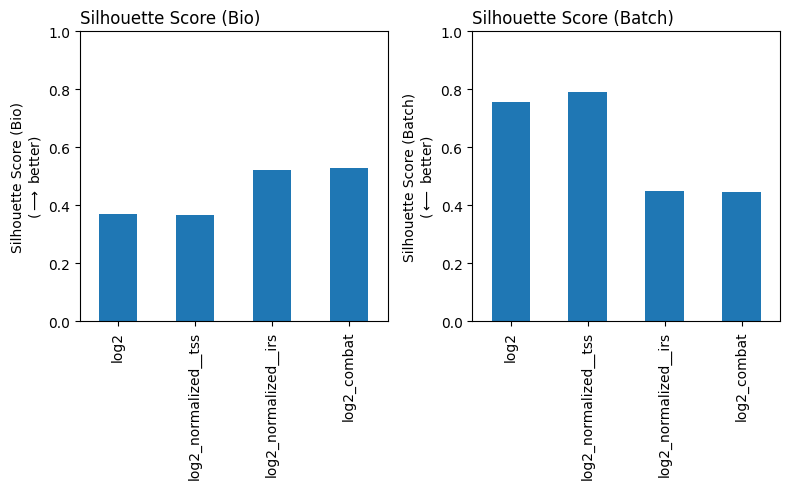

In [ ]:
silhouette_scores = {}

for layer in LAYERS:
    silhouette_scores[layer] = {
        "batch": silhouette_label(adata.layers[layer], labels=adata.obs["plex"]),
        "bio": silhouette_label(adata.layers[layer], labels=adata.obs["timepoint"]),
    }

silhouette_scores = pd.DataFrame.from_dict(silhouette_scores, orient="index")

fig, axs = plt.subplots(1, 2, figsize=(8, 5))
silhouette_scores.plot.bar(y="bio", ax=axs[0], legend=False)
axs[0].set_ylabel("Silhouette Score (Bio)\n($\\longrightarrow$ better)")
axs[0].set_title("Silhouette Score (Bio)", loc="left")

silhouette_scores.plot.bar(y="batch", ax=axs[1], legend=False)
axs[1].set_ylabel("Silhouette Score (Batch)\n($\\longleftarrow$ better)")
axs[1].set_title("Silhouette Score (Batch)", loc="left")


for ax in axs.ravel():
    ax.set_ylim(0, 1)

plt.tight_layout()

plt.show()